## Seq2Seq
- 실생활 예시 : 번역 or 챗봇
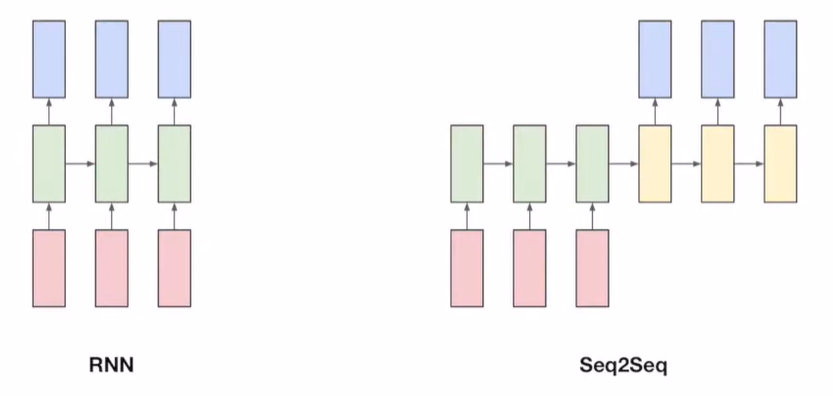
- RNN 모델은 문장이 들어올 때마다 출력을 만들어서 답변을 낼 것이다. 사용자가 원하는 답변을 챗봇으로부터 얻을 수 없을 것이다. 
- 문장을 다 듣기 전에 생성하면 적절하지 않은 답변 출력 가능성 높음. 

### 대표적인 특징 : encoder - decoder
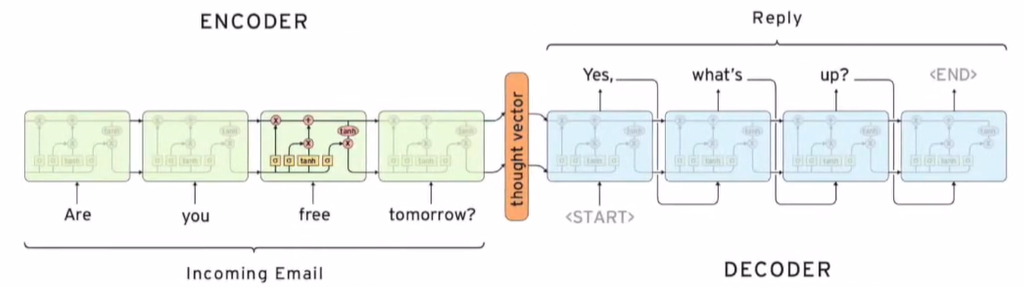
- encoder : 입력된 단어 시퀀스를 어떤 벡터의 형태로 압축함. 압축된 형태의 벡터를 디코더로 전달.
- decoder : 인코더로부터 받은 벡터를 hidden state에 start flag와 함께 넣음. 이 셀에서 나온 단어가 reply의 첫 단어. 그 단어가 두 번째 cell에 들어가서 전 셀의 hidden state와 함께 다음 단어 예측. 
- 인코더에서 모든 문장을 들은 후에 디코더가 문장을 출력함. 

#### preprocess
번역 task에서는 source text를 target text로 바꿈.
- 영어 문장을 한국어 문장으로 번역하면 잘 된 모델.
- 기본적으로 source와 target을 train 과 test set으로 나눠서 s->t train set으로 학습하고 test set으로 평가. 
- preprocess : 각각의 source text가 몇 개의 단어로 되어 있는지, 해당 단어가 뭔지 등을 찾는 것 + 마찬가지로 target text에서도 몇 개의 단어로 되어 있고 어떤 단어가 있는지 찾아내는 과정 + train/test로 나누는 과정 

In [33]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

raw = ["I feel hungry.	나는 배가 고프다.",
       "Pytorch is very easy.	파이토치는 매우 쉽다.",
       "Pytorch is a framework for deep learning.	파이토치는 딥러닝을 위한 프레임워크이다.",
       "Pytorch is very clear to use.	파이토치는 사용하기 매우 직관적이다."]

SOS_token = 0 # 문장 시작 토큰
EOS_token = 1 # end of sentence 문장 끝날 때 해당 토큰 사용 

In [23]:
class Vocab:
    def __init__(self):
        self.vocab2index = {"<SOS>":SOS_token, "<EOS>":EOS_token}
        self.index2vocab = {SOS_token:"<SOS>", EOS_token:"<EOS>"}
        self.vocab_count = {}
        self.n_vocab = len(self.vocab2index)

    def add_vocab(self, sentence):
        for word in sentence.split(" "):
            if word not in self.vocab2index:
                self.vocab2index[word] = self.n_vocab
                self.vocab_count[word] = 1
                self.index2vocab[self.n_vocab] = word
                self.n_vocab += 1
            else:
                self.vocab_count[word] += 1

In [24]:
# filter out the long sentence from source and target data
# max_length 보다 짧은 문장들만 골라내 학습 효율성 높임
def filter_pair(pair, source_max_length, target_max_length):
    return len(pair[0].split(" ")) < source_max_length and len(pair[1].split(" "))

In [25]:
# 모델이 잘 학습할 수 있도록 데이터를 준비하는 과정

def preprocess(corpus, source_max_length, target_max_length):
    print("reading corpus...")
    pairs = []
    for line in corpus:
        # 대문자를 소문자로 통일
        # 탭을 기준으로 source 문장과 target 문장 분리
        pairs.append([s for s in line.strip().lower().split("\t")])
    print("Read {} sentence pairs".format(len(pairs)))

    # 필터링 : 너무 긴 문장 쳐냄
    pairs = [pair for pair in pairs if filter_pair(pair, source_max_length, target_max_length)]
    print("Trimmed to {} sentence pairs".format(len(pairs)))

    source_vocab = Vocab()
    target_vocab = Vocab()

    # Counting : 남은 문장들을 훑으며 단어 사전 완성
    print("Counting words...")
    for pair in pairs:
        source_vocab.add_vocab(pair[0])
        target_vocab.add_vocab(pair[1])
    print("source vocab size =", source_vocab.n_vocab)
    print("target vocab size =", target_vocab.n_vocab)

    return pairs, source_vocab, target_vocab

### embedding
- 거대한 행렬. 
- input size는 src text를 이루고 있는 단어의 개수
- embedding 행렬과 one-hot encoding vector가 곱해지면 hidden size크기의 벡터가 만들어지고 이것이 GRU로 들어감. 

In [26]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, x, hidden):
        x = self.embedding(x).view(1, 1, -1)
        # .view(1, 1, -1) : 데이터의 내용은 그대로 두고 차원만 바꾸는 함수
        # 첫 번째 1 : batch size -> 한 번에 문장 1개씩 처리
        # 두 번째 1 : sequence length -> 한 번에 단어 1개씩 입력으로 넣을 것.
        # 세 번째 -1 : 나머지 전부. 남은 차원을 컴퓨터가 알아서 계산해 채우라는 뜻. 
        x, hidden = self.gru(x, hidden)
        return x, hidden

In [27]:
class Decoder(nn.Module):
    def __init__ (self, hidden_size, output_size):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        # onehot에 emb를 곱하는 거라서 output_size x hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

        # out layer는 hidden_size 벡터를 output 사이즈(target size)로 늘려야함. 
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim = 1)

    def forward(self, x, hidden):
        x = self.embedding(x).view(1, 1, -1)
        x, hidden = self.gru(x, hidden)
        x = self.softmax(self.out(x[0]))
        return x, hidden

In [28]:
# sentence를 one-hot vector로 만들어주는 함수
def tensorize(vocab, sentence):
    indexes = [vocab.vocab2index[word] for word in sentence.split(" ")]
    indexes.append(vocab.vocab2index["<EOS>"])
    return torch.Tensor(indexes).long().to(device).view(-1, 1)

In [ ]:
def train(pairs, source_vocab, target_vocab, encoder, decoder, n_iter, print_every=1000, learning_rate=0.01):
    loss_total = 0

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    training_batch = [random.choice(pairs) for _ in range(n_iter)]
    training_source = [tensorize(source_vocab, pair[0]) for pair in training_batch]
    training_target = [tensorize(target_vocab, pair[1]) for pair in training_batch]

    criterion = nn.NLLLoss()

    for i in range(1, n_iter + 1):
        source_tensor = training_source[i - 1]
        target_tensor = training_target[i - 1]

        encoder_hidden = torch.zeros([1, 1, encoder.hidden_size]).to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        source_length = source_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        for enc_input in range(source_length):
            _, encoder_hidden = encoder(source_tensor[enc_input], encoder_hidden)

        decoder_input = torch.Tensor([[SOS_token]]).long().to(device)
        decoder_hidden = encoder_hidden # encoder의 마지막 hidden state를
        # decoder의 첫 hidden state로 넣어 줌. 

        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di] # teacher forcing : GRU에 다음 예측값을 넣지 않고 그냥 타겟값을 넣어 좀 더 빨리 학습 가능  

        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        loss_iter = loss.item() / target_length
        loss_total += loss_iter

        if i % print_every == 0:
            loss_avg = loss_total / print_every
            loss_total = 0
            print("[{} - {}%] loss = {:05.4f}".format(i, i / n_iter * 100, loss_avg))

In [30]:
# insert given sentence to check the training

def evaluate(pairs, source_vocab, target_vocab, encoder, decoder, target_max_length):
    for pair in pairs:
        print(">", pair[0])
        print("=", pair[1])

        source_tensor = tensorize(source_vocab, pair[0])
        source_length = source_tensor.size()[0]
        encoder_hidden = torch.zeros([1, 1, encoder.hidden_size]).to(device)

        for ei in range(source_length):
            _, encoder_hidden = encoder(source_tensor[ei], encoder_hidden)
        
        decoder_input = torch.Tensor([[SOS_token]], device=device).long()
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(target_max_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            _, top_index = decoder_output.data.topk(1)
            if top_index.item() == EOS_token:
                decoded_words.append("<EOS>")
                break
            else:
                decoded_words.append(target_vocab.index2vocab[top_index.item()])

            decoder_input = top_index.squeeze().detach()
        
        predict_words = decoded_words
        predict_sentence = " ".join(predict_words)
        print("<", predict_sentence)
        print("")

In [31]:
# declare max length for sentence
SOURCE_MAX_LENGTH = 10
TARGET_MAX_LENGTH = 12

In [36]:
# preprocess the corpus
load_pairs, load_source_vocab, load_target_vocab = preprocess(raw, SOURCE_MAX_LENGTH, TARGET_MAX_LENGTH)
print(random.choice(load_pairs))

reading corpus...
Read 4 sentence pairs
Trimmed to 4 sentence pairs
Counting words...
source vocab size = 17
target vocab size = 13
['pytorch is a framework for deep learning.', '파이토치는 딥러닝을 위한 프레임워크이다.']


In [38]:
enc_hidden_size = 16
dec_hidden_size = enc_hidden_size
enc = Encoder(load_source_vocab.n_vocab, enc_hidden_size).to(device)
dec = Decoder(dec_hidden_size, load_target_vocab.n_vocab).to(device)

In [39]:
# train seq2seq model
train(load_pairs, load_source_vocab, load_target_vocab, enc, dec, 5000, print_every=1000)

AttributeError: 'int' object has no attribute 'backward'